# Traffic Light Detection using Image Processing
### Milestone 2 – MCTR1010

**Team Members:**  
- Ahmed Mostafa
- Hazim Ashraf
- Moustafa Abuelmagd
- Farida Gamal
- Abdullah Eid

---

## Objective
The goal of this milestone is to design a vision-based system that detects traffic light signals (Red, Yellow, Green) and outputs corresponding commands (STOP, SLOW, GO).

This system uses:
- Geometric transformations
- Intensity transformations
- Neighborhood operations
- Color-based segmentation (HSV)

---

## Application
This system can be used in autonomous vehicles or robotic platforms to make real-time driving decisions.

## ⚙️ Processing Pipeline

1. Image Acquisition  
2. Geometric Transformations  
   - Cropping (Region of Interest 'ROI')  
   - Resizing  
3. Intensity Transformations  
   - Brightness Adjustment  
   - Contrast Enhancement (CLAHE)  
4. Neighborhood Operation  
   - Gaussian Blur  
5. Color Space Conversion  
   - RGB → HSV  
6. Color Segmentation (Masking)
   - Red, Yellow, Green masks  
7. Decision Making  
   - STOP / SLOW / GO  

---

Each step improves the image quality and helps in accurate detection.

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Kernel and Environment Check (For Evaluation)
If the notebook does not run immediately, select the `vision_env` or `.venv` Python 3.12 kernel, then run the next cell.

In [14]:
import sys
import cv2
import numpy as np
import matplotlib

print("Python executable:", sys.executable)
print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)
print("Matplotlib version:", matplotlib.__version__)

Python executable: /home/ahmed/vision_env/bin/python
OpenCV version: 4.13.0
NumPy version: 2.4.3
Matplotlib version: 3.10.8


In [15]:
def show(title, image, cmap=None):
    plt.figure(figsize=(5,5))
    plt.title(title)
    
    if cmap:
        plt.imshow(image, cmap=cmap)
    else:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    
    plt.axis('off')

## 📷 Step 1: Image Acquisition

We start by loading an input image that contains a traffic light.

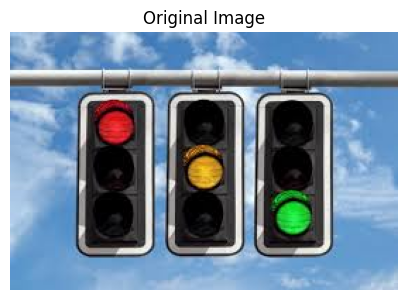

In [16]:
image = cv2.imread("trafficlight.jpeg")  

if image is None:
    raise Exception("Image not found!")

show("Original Image", image)

## Step 2: Geometric Transformations
We apply geometric operations to focus on the traffic-light region and normalize image size.

- Crop right side as Region of Interest (ROI)
- Resize to a fixed resolution for consistent processing

**Assumption for future milestones:** In our testbed, traffic lights and signs are assumed to be on the right side of the road. Therefore, we will use the right half of the image as the ROI.

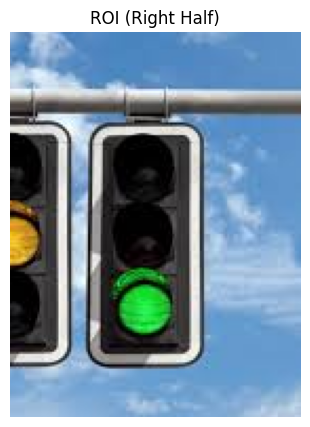

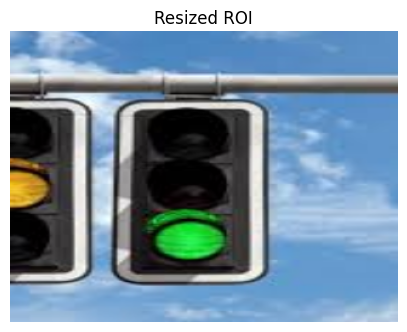

In [17]:
# Crop right half (ROI)
h, w, _ = image.shape
roi = image[:, w//2:w]

# Resize to standard size
resized = cv2.resize(roi, (320, 240))

show("ROI (Right Half)", roi)
show("Resized ROI", resized)

## Step 3: Intensity Transformations
We improve visibility using brightness adjustment and contrast enhancement (CLAHE).

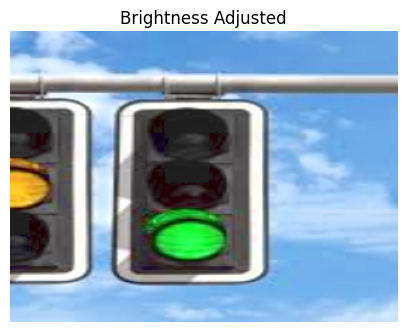

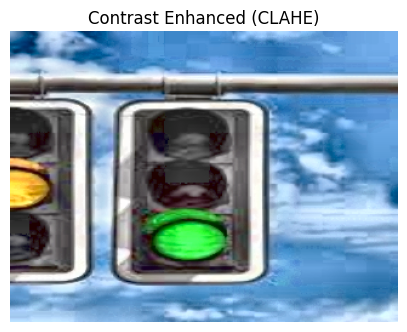

In [18]:
# Brightness adjustment in HSV
hsv_tmp = cv2.cvtColor(resized, cv2.COLOR_BGR2HSV)
h_ch, s_ch, v_ch = cv2.split(hsv_tmp)
v_ch = cv2.add(v_ch, 30)
hsv_bright = cv2.merge((h_ch, s_ch, v_ch))
bright = cv2.cvtColor(hsv_bright, cv2.COLOR_HSV2BGR)

# CLAHE on L channel in LAB
lab = cv2.cvtColor(bright, cv2.COLOR_BGR2LAB)
l_ch, a_ch, b_ch = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
l_eq = clahe.apply(l_ch)
contrast = cv2.cvtColor(cv2.merge((l_eq, a_ch, b_ch)), cv2.COLOR_LAB2BGR)

show("Brightness Adjusted", bright)
show("Contrast Enhanced (CLAHE)", contrast)

## Step 4: Neighborhood Operation
Gaussian blur reduces high-frequency noise before color segmentation.

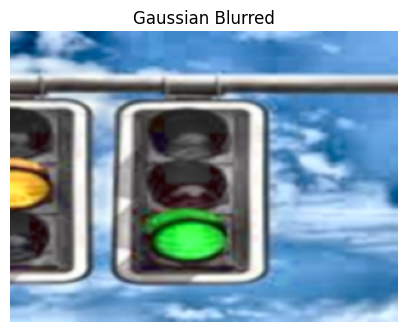

In [19]:
blurred = cv2.GaussianBlur(contrast, (5, 5), 0)
show("Gaussian Blurred", blurred)

## Step 5: Color Space Conversion and Segmentation
We convert to HSV and build masks for Red, Yellow, and Green ranges.

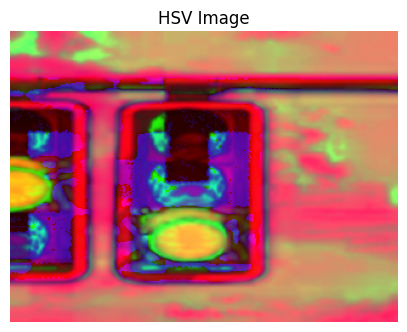

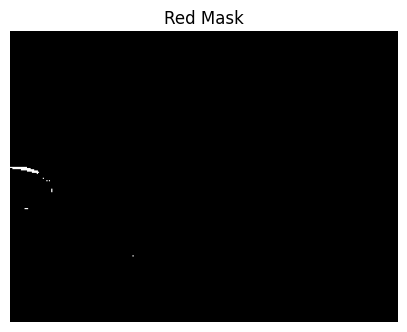

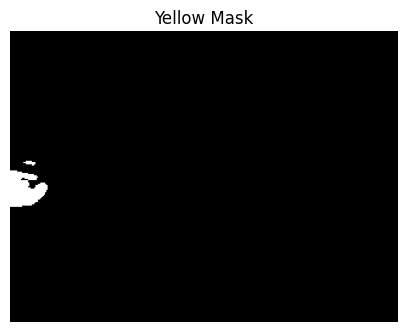

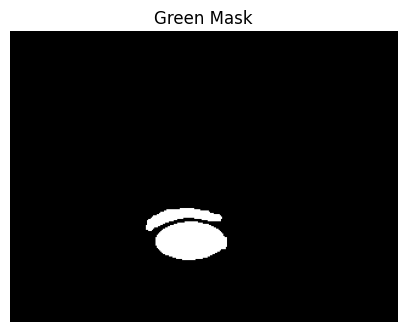

In [20]:
hsv_img = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)

# Red has two HSV ranges
lower_red1 = np.array([0, 120, 70])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 120, 70])
upper_red2 = np.array([179, 255, 255])

lower_yellow = np.array([20, 100, 100])
upper_yellow = np.array([30, 255, 255])

lower_green = np.array([35, 100, 100])
upper_green = np.array([85, 255, 255])

red_mask = cv2.inRange(hsv_img, lower_red1, upper_red1) + cv2.inRange(hsv_img, lower_red2, upper_red2)
yellow_mask = cv2.inRange(hsv_img, lower_yellow, upper_yellow)
green_mask = cv2.inRange(hsv_img, lower_green, upper_green)

show("HSV Image", hsv_img)
show("Red Mask", red_mask, cmap="gray")
show("Yellow Mask", yellow_mask, cmap="gray")
show("Green Mask", green_mask, cmap="gray")

## Step 6: Decision Making (STOP / SLOW / GO)
The command is selected using mask pixel counts and a threshold.

In [21]:
red_pixels = int(np.sum(red_mask > 0))
yellow_pixels = int(np.sum(yellow_mask > 0))
green_pixels = int(np.sum(green_mask > 0))

threshold = 200
counts = {
    "STOP": red_pixels,
    "SLOW": yellow_pixels,
    "GO": green_pixels
}

best_command = max(counts, key=counts.get)
best_count = counts[best_command]

if best_count > threshold:
    command = best_command
else:
    command = "NO_SIGNAL"

print(f"Red pixels    : {red_pixels}")
print(f"Yellow pixels : {yellow_pixels}")
print(f"Green pixels  : {green_pixels}")
print(f"Final command : {command}")

Red pixels    : 66
Yellow pixels : 679
Green pixels  : 1980
Final command : GO


## Step 7: Per-Third Validation (Left / Middle / Right)
This test checks each image third independently to verify expected detections:
- Left third -> STOP (Red)
- Middle third -> SLOW (Yellow)
- Right third -> GO (Green)

Left third   -> STOP      | R=3412, Y=0, G=0
Middle third -> SLOW      | R=203, Y=1692, G=0
Right third  -> GO        | R=7, Y=2, G=3072


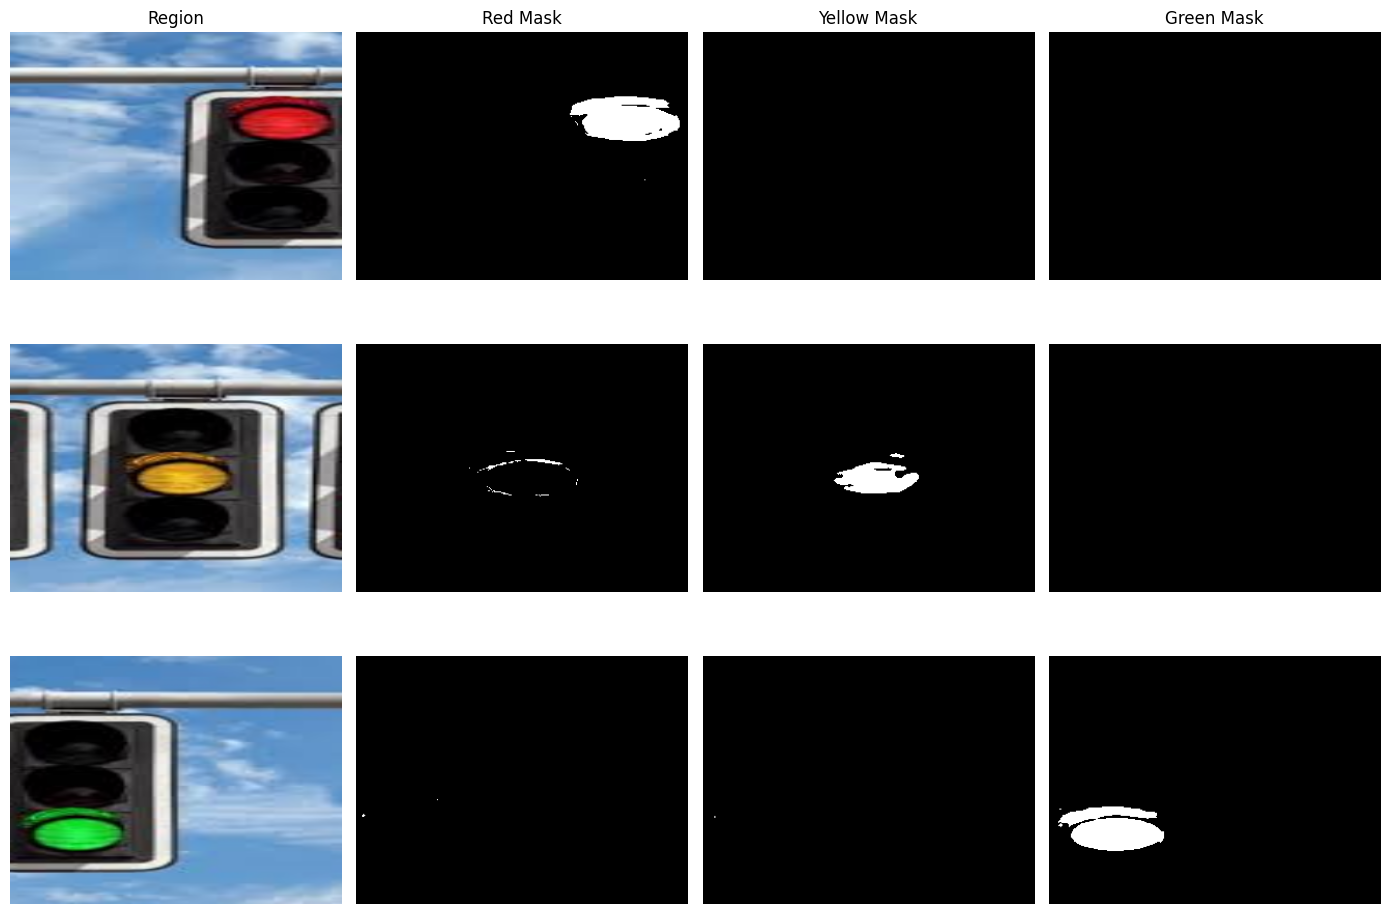

In [22]:
def detect_command_on_patch(patch_bgr, threshold=200):
    patch_resized = cv2.resize(patch_bgr, (320, 240))

    hsv_tmp = cv2.cvtColor(patch_resized, cv2.COLOR_BGR2HSV)
    h_ch, s_ch, v_ch = cv2.split(hsv_tmp)
    v_ch = cv2.add(v_ch, 30)
    hsv_bright = cv2.merge((h_ch, s_ch, v_ch))
    bright = cv2.cvtColor(hsv_bright, cv2.COLOR_HSV2BGR)

    lab = cv2.cvtColor(bright, cv2.COLOR_BGR2LAB)
    l_ch, a_ch, b_ch = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l_eq = clahe.apply(l_ch)
    contrast = cv2.cvtColor(cv2.merge((l_eq, a_ch, b_ch)), cv2.COLOR_LAB2BGR)

    blurred = cv2.GaussianBlur(contrast, (5, 5), 0)
    hsv_img = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)

    red = cv2.inRange(hsv_img, lower_red1, upper_red1) + cv2.inRange(hsv_img, lower_red2, upper_red2)
    yellow = cv2.inRange(hsv_img, lower_yellow, upper_yellow)
    green = cv2.inRange(hsv_img, lower_green, upper_green)

    red_pixels = int(np.sum(red > 0))
    yellow_pixels = int(np.sum(yellow > 0))
    green_pixels = int(np.sum(green > 0))

    counts = {"STOP": red_pixels, "SLOW": yellow_pixels, "GO": green_pixels}
    best_command = max(counts, key=counts.get)
    command = best_command if counts[best_command] > threshold else "NO_SIGNAL"

    return command, counts, (patch_resized, red, yellow, green)

h_img, w_img, _ = image.shape
third_w = w_img // 3
regions = {
    "Left third": image[:, :third_w],
    "Middle third": image[:, third_w:2*third_w],
    "Right third": image[:, 2*third_w:]
}

results = {}
for name, patch in regions.items():
    results[name] = detect_command_on_patch(patch, threshold=200)

for name in ["Left third", "Middle third", "Right third"]:
    command, counts, _ = results[name]
    print(f"{name:12s} -> {command:9s} | R={counts['STOP']}, Y={counts['SLOW']}, G={counts['GO']}")

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
col_titles = ["Region", "Red Mask", "Yellow Mask", "Green Mask"]
for c, title in enumerate(col_titles):
    axes[0, c].set_title(title)

row_names = ["Left third", "Middle third", "Right third"]
for r, row_name in enumerate(row_names):
    command, counts, (patch_resized, red_m, yellow_m, green_m) = results[row_name]

    axes[r, 0].imshow(cv2.cvtColor(patch_resized, cv2.COLOR_BGR2RGB))
    axes[r, 0].set_ylabel(f"{row_name}\n{command}", fontsize=10)
    axes[r, 1].imshow(red_m, cmap="gray")
    axes[r, 2].imshow(yellow_m, cmap="gray")
    axes[r, 3].imshow(green_m, cmap="gray")

    for c in range(4):
        axes[r, c].axis("off")

plt.tight_layout()
plt.show()

In [23]:
# Automatic pass/fail check for per-third validation
expected = {
    "Left third": "STOP",
    "Middle third": "SLOW",
    "Right third": "GO"
}

all_passed = True
for name in ["Left third", "Middle third", "Right third"]:
    predicted = results[name][0]
    exp = expected[name]
    ok = predicted == exp
    all_passed = all_passed and ok
    status = "PASS" if ok else "FAIL"
    print(f"{name:12s}: expected={exp:5s}, predicted={predicted:9s} -> {status}")

print("\nOverall validation:", "PASS" if all_passed else "FAIL")

Left third  : expected=STOP , predicted=STOP      -> PASS
Middle third: expected=SLOW , predicted=SLOW      -> PASS
Right third : expected=GO   , predicted=GO        -> PASS

Overall validation: PASS


## Milestone 2 Requirements Checklist
- Image Acquisition: done
- Geometric Transformations (Crop + Resize): done
- Intensity Transformations (Brightness + CLAHE): done
- Neighborhood Operation (Gaussian Blur): done
- HSV Color Segmentation (Red, Yellow, Green): done
- Decision Output (STOP / SLOW / GO): done

## Notes for Evaluation
1. Open `ms2.ipynb`.
2. Use the `vision_env` or `.venv` Python 3.12 kernel.
3. Run all cells from top to bottom.